In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df =pd.read_csv("/content/drive/MyDrive/cleaned_credit-card-transactions_dataset.csv")
df.head()

,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,...,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud,hour,age,age_group
0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,Moravian Falls,...,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0,0,38,Middle-aged (31-50)
1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,Orient,...,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0,0,48,Middle-aged (31-50)
2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,Malad City,...,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0,0,64,Older (>50)
3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,Boulder,...,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0,0,59,Older (>50)
4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,Doe Hill,...,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0,0,40,Middle-aged (31-50)


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1296675 entries, 0 to 1296674
Data columns (total 25 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   trans_date_trans_time  1296675 non-null  object 
 1   cc_num                 1296675 non-null  int64  
 2   merchant               1296675 non-null  object 
 3   category               1296675 non-null  object 
 4   amt                    1296675 non-null  float64
 5   first                  1296675 non-null  object 
 6   last                   1296675 non-null  object 
 7   gender                 1296675 non-null  object 
 8   street                 1296675 non-null  object 
 9   city                   1296675 non-null  object 
 10  state                  1296675 non-null  object 
 11  zip                    1296675 non-null  int64  
 12  lat                    1296675 non-null  float64
 13  long                   1296675 non-null  float64
 14  city_pop          

In [5]:
# Target variable distribution
df["is_fraud"].value_counts()

,count
is_fraud,
0,1289169
1,7506


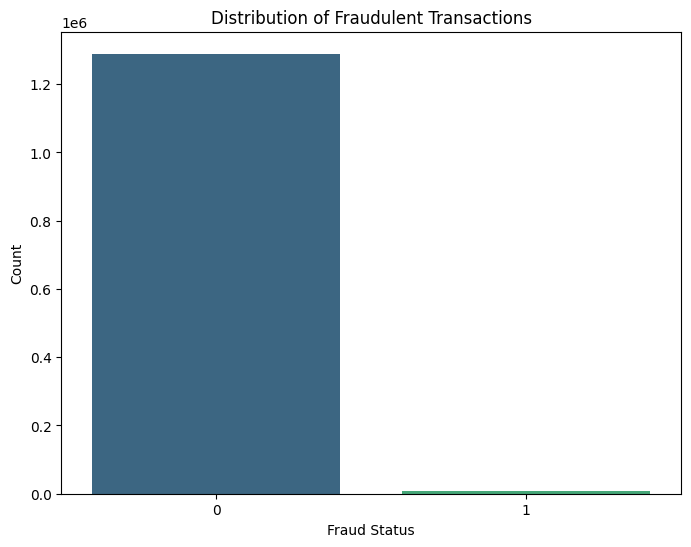

In [ ]:
# Target Class distribution
plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='is_fraud', hue='is_fraud', palette='viridis', legend=False)
plt.title('Distribution of Fraudulent Transactions')
plt.xlabel('Fraud Status')
plt.ylabel('Count')
plt.show()

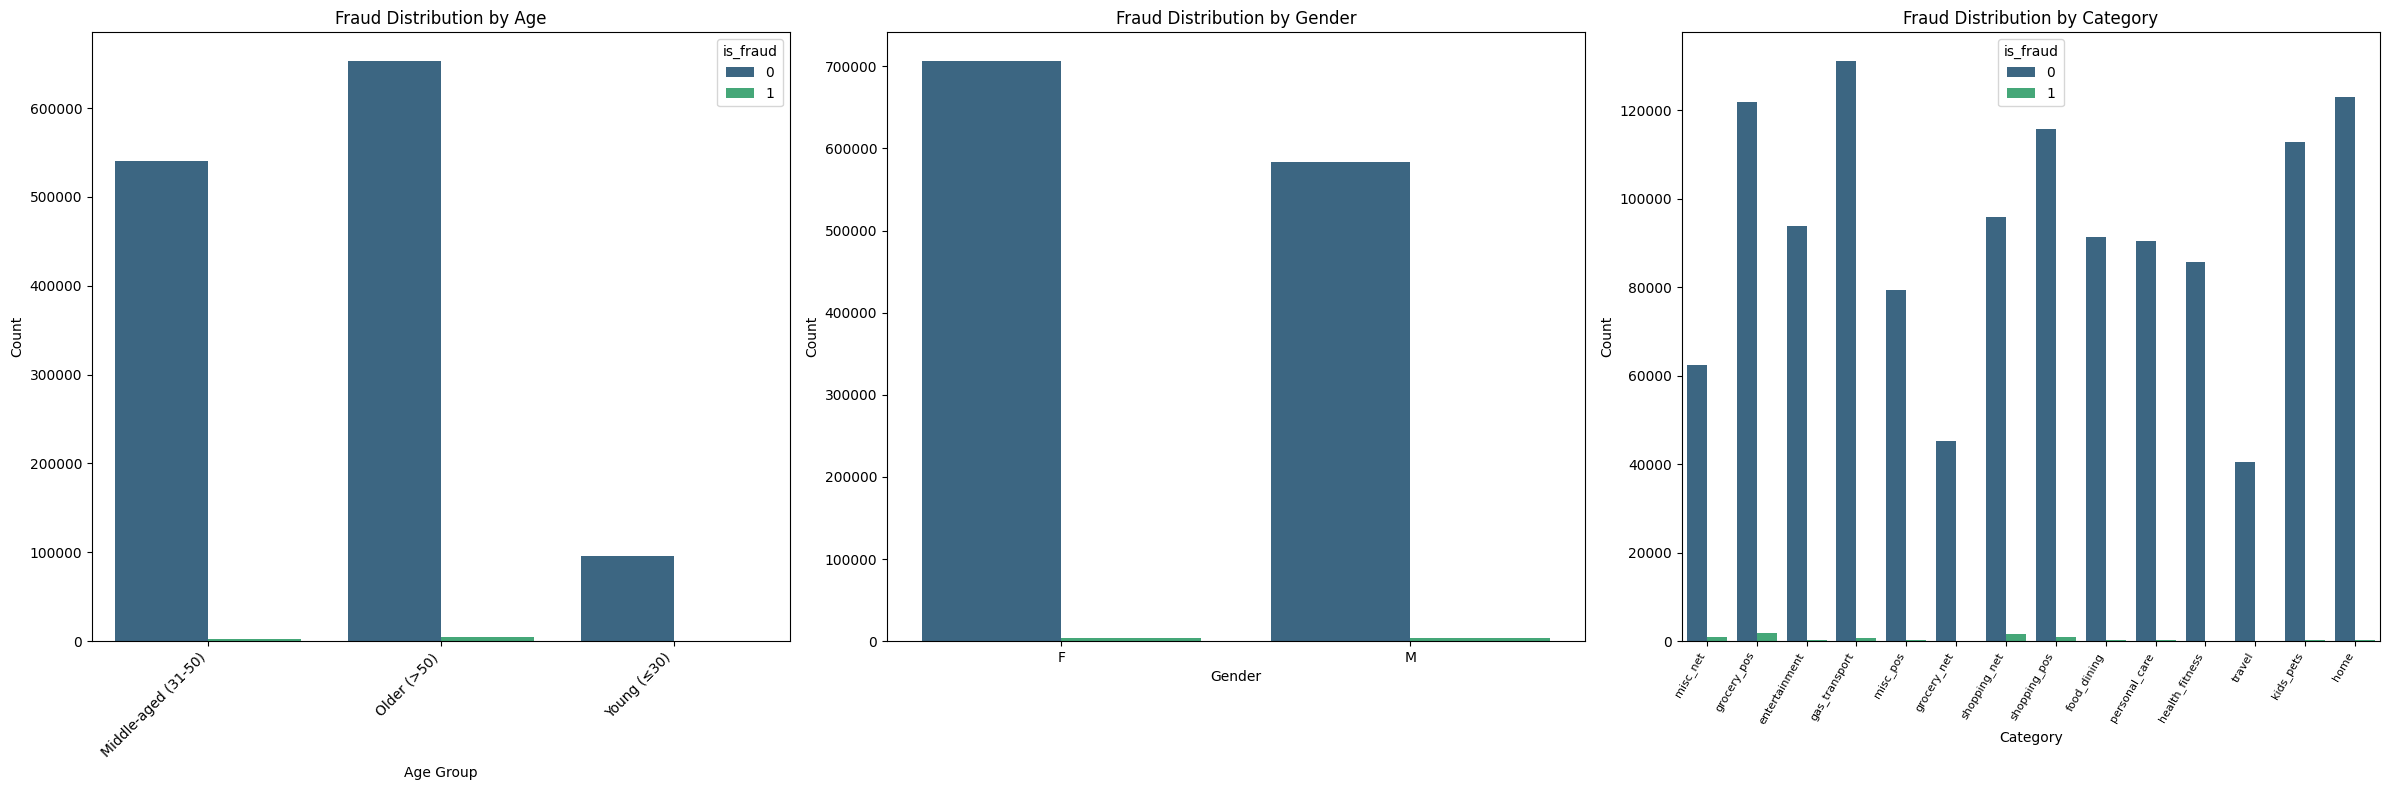

In [ ]:
plt.figure(figsize=(24, 8))

# Fraud distribution by Age
plt.subplot(1, 3, 1)
sns.countplot(data=df, x='age_group', hue='is_fraud', palette='viridis', legend=True)
plt.title('Fraud Distribution by Age')
plt.xlabel('Age Group')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right') # Rotate for better readability

# Fraud Distribution by Gender
plt.subplot(1, 3, 2)
sns.countplot(data=df, x='gender', hue='is_fraud', palette='viridis', legend=False)
plt.title('Fraud Distribution by Gender')
plt.xlabel('Gender')
plt.ylabel('Count')

# Fraud Distribution by Category
plt.subplot(1, 3, 3)
sns.countplot(data=df, x='category', hue='is_fraud', palette='viridis', legend=True)
plt.title('Fraud Distribution by Category')
plt.xlabel('Category')
plt.ylabel('Count')
plt.xticks(rotation=60, ha='right', fontsize=8)

plt.tight_layout()
plt.show()

###***MODEL ARCHITECTURE***

Isolation Forest is an unsupervised anomaly detection algorithm. It works on the assumption that:
* Normal observations are common.
* Anomalies (fraudulent transactions) are rare and different from the majority.

If you artificially balance the data by oversampling fraud (e.g., using SMOTE) or undersampling normal transactions, you change this natural distribution. The model may no longer learn what "normal" behavior looks like, making anomaly detection less effective.

In [ ]:
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score,roc_auc_score

In [ ]:
# Preprocess data
# select features that describe transaction behavior, not identity
selected_features = ["amt", "city_pop", "gender", "city", "state", "job", "lat", "long",
                     "merch_lat", "merch_long"]
X = df[selected_features].copy()

In [ ]:
X.head()

,amt,city_pop,gender,city,state,job,lat,long,merch_lat,merch_long
0,4.97,3495,F,Moravian Falls,NC,"Psychologist, counselling",36.0788,-81.1781,36.011293,-82.048315
1,107.23,149,F,Orient,WA,Special educational needs teacher,48.8878,-118.2105,49.159047,-118.186462
2,220.11,4154,M,Malad City,ID,Nature conservation officer,42.1808,-112.2620,43.150704,-112.154481
3,45.00,1939,M,Boulder,MT,Patent attorney,46.2306,-112.1138,47.034331,-112.561071
4,41.96,99,M,Doe Hill,VA,Dance movement psychotherapist,38.4207,-79.4629,38.674999,-78.632459


In [ ]:
# Fraud often happens far from the cardholder's normally activities.
def distance(lat1, lon1, lat2, lon2):     # using the Haversine formula
    R = 6371  # Earth radius in km
    dlat, dlon = np.radians(lat2 - lat1), np.radians(lon2 - lon1)
    a = np.sin(dlat/2)**2 + np.cos(np.radians(lat1)) * np.cos(np.radians(lat2)) * np.sin(dlon/2)**2
    return 2 * R * np.arcsin(np.sqrt(a))

df["distance_km"] = distance(df["lat"], df["long"], df["merch_lat"], df["merch_long"])
X["distance_km"] = df["distance_km"]

In [ ]:
X.head()

,amt,city_pop,gender,city,state,job,lat,long,merch_lat,merch_long,distance_km
0,4.97,3495,F,Moravian Falls,NC,"Psychologist, counselling",36.0788,-81.1781,36.011293,-82.048315,78.597568
1,107.23,149,F,Orient,WA,Special educational needs teacher,48.8878,-118.2105,49.159047,-118.186462,30.212176
2,220.11,4154,M,Malad City,ID,Nature conservation officer,42.1808,-112.2620,43.150704,-112.154481,108.206083
3,45.00,1939,M,Boulder,MT,Patent attorney,46.2306,-112.1138,47.034331,-112.561071,95.673231
4,41.96,99,M,Doe Hill,VA,Dance movement psychotherapist,38.4207,-79.4629,38.674999,-78.632459,77.556744


In [ ]:
# Label encoding on categorical columns
categorical_cols = X.select_dtypes(include="object").columns
le = LabelEncoder()
for col in categorical_cols:
    X[col] = le.fit_transform(X[col].astype(str))

In [ ]:
X.head()

,amt,city_pop,gender,city,state,job,lat,long,merch_lat,merch_long
0,4.97,3495,0,526,27,370,36.0788,-81.1781,36.011293,-82.048315
1,107.23,149,0,612,47,428,48.8878,-118.2105,49.159047,-118.186462
2,220.11,4154,1,468,13,307,42.1808,-112.2620,43.150704,-112.154481
3,45.00,1939,1,84,26,328,46.2306,-112.1138,47.034331,-112.561071
4,41.96,99,1,216,45,116,38.4207,-79.4629,38.674999,-78.632459


In [ ]:
# One-hot encoding on columns with small number of unique values
X = pd.concat([X, pd.get_dummies(df["category"], prefix="cat")], axis=1)

In [ ]:
X.head()

,amt,city_pop,hour,age,gender,city,state,job,lat,long,...,cat_grocery_pos,cat_health_fitness,cat_home,cat_kids_pets,cat_misc_net,cat_misc_pos,cat_personal_care,cat_shopping_net,cat_shopping_pos,cat_travel
0,4.97,3495,0,38,0,526,27,370,36.0788,-81.1781,...,False,False,False,False,True,False,False,False,False,False
1,107.23,149,0,48,0,612,47,428,48.8878,-118.2105,...,True,False,False,False,False,False,False,False,False,False
2,220.11,4154,0,64,1,468,13,307,42.1808,-112.2620,...,False,False,False,False,False,False,False,False,False,False
3,45.00,1939,0,59,1,84,26,328,46.2306,-112.1138,...,False,False,False,False,False,False,False,False,False,False
4,41.96,99,0,40,1,216,45,116,38.4207,-79.4629,...,False,False,False,False,False,True,False,False,False,False


In [ ]:
# Split data
y = df["is_fraud"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,     # to preserve the class proportions, else model acts as though fraud is non-existent.
    random_state=42
)

In [ ]:
# Scaling numerical features since variables like transaction amount, city population, and distance have very different ranges.
# Although Isolation Forest does not strictly require scaling, it helps create a more consistent dataset and is considered good practice in ML workflows.

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [ ]:
# Training the model
# contamination implies the % of data we expect to be fraud
fraud_rate = df["is_fraud"].mean()
print(f"Actual fraud rate: {fraud_rate:.4%}")

iso_forest = IsolationForest(
    n_estimators=100,
    contamination=fraud_rate,
    random_state=42,

)

iso_forest.fit(X_train_scaled)

Actual fraud rate: 0.5789%


,n_estimators,100
,max_samples,'auto'
,contamination,np.float64(0....8651743883394)
,max_features,1.0
,bootstrap,False
,n_jobs,None
,random_state,42
,verbose,0
,warm_start,False


In [ ]:
# Model Prediction
pred = iso_forest.predict(X_test_scaled)     #displays 1=Normal, -1=Fraud

pred = [1 if p == -1 else 0 for p in pred]   #converts to 0=Normal, 1=Fraud

pred

[0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,


[[256442   1392]
 [  1431     70]]
--- ISOLATION FOREST PERFORMANCE EVALUATION ---
              precision    recall  f1-score   support

       Legit       0.99      0.99      0.99    257834
       Fraud       0.05      0.05      0.05      1501

    accuracy                           0.99    259335
   macro avg       0.52      0.52      0.52    259335
weighted avg       0.99      0.99      0.99    259335



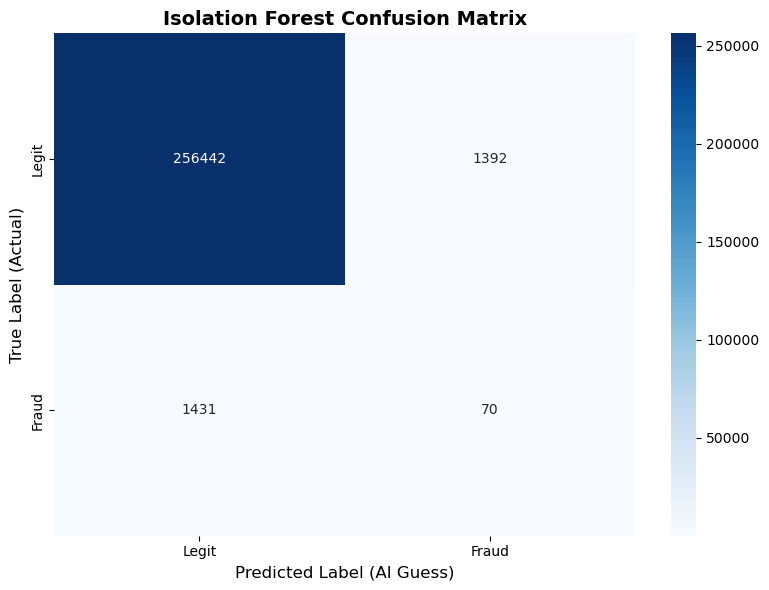

In [ ]:
import matplotlib.pyplot as  plt
import seaborn as sns

print(confusion_matrix(y_test, pred))


print("--- ISOLATION FOREST PERFORMANCE EVALUATION ---")
print(classification_report(y_test, pred, target_names=['Legit', 'Fraud']))

# Step 8: Generate and plot the Visual Confusion Matrix
cm = confusion_matrix(y_test, pred)

plt.figure(figsize=(8, 6))
labels = ['Legit', 'Fraud']

# Create the colored heatmap plot
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=labels,
    yticklabels=labels,
    cbar=True
)

# Add clear titles and labels
plt.title('Isolation Forest Confusion Matrix', fontsize=14, fontweight='bold')
plt.ylabel('True Label (Actual)', fontsize=12)
plt.xlabel('Predicted Label (AI Guess)', fontsize=12)
plt.tight_layout()

# Display the plot on your screen
plt.show()


##**EVALUATION**

These results show that this model is excellent at identifying normal transactions but struggles to identify fraudulent ones, which is common for unsupervised anomaly detection.

1. **Confusion Matrix**
* True Positives (81): Fraud correctly detected.
* False Positives (1380): Legitimate transactions incorrectly flagged as fraud.
* False Negatives (1420): Fraudulent transactions that were missed.
* True Negatives (256454): Legitimate transactions correctly identified.

2. **Precision**

Fraud (Class 1): Precision = 0.06 (6%)

Of all the transactions the model predicted as fraud, only 6% were actually fraudulent.
This means the model produces many false alarms.

3. **Recall**

Fraud (Class 1): Recall = 0.05 (5%)

The model detected only 5% of all actual fraud cases.
It missed 95% of fraudulent transactions, which is a major weakness for fraud detection.

4. **F1-Score**

Fraud (Class 1): F1-score = 0.05

The F1-score combines precision and recall into a single measure.
A score of 0.05 indicates poor fraud detection performance.

5. **Accuracy**

Accuracy = 99%

At first glance, this looks excellent.
However, because almost all transactions are legitimate, predicting "normal" most of the time still results in very high accuracy.
Accuracy is therefore misleading for this highly imbalanced dataset.

6. **Macro Average**

Macro Average = 0.52

This gives equal importance to both classes (normal and fraud).
The relatively low score shows that the model performs poorly on the minority (fraud) class.

7. **Weighted Average**

Weighted Average = 0.99

This average is heavily influenced by the large number of legitimate transactions.
Since the model performs very well on normal transactions, the weighted score appears very high despite poor fraud detection.

**Conclusion**

The Isolation Forest was effective at recognizing normal transaction patterns but had limited ability to detect fraudulent transactions in this dataset. This outcome is not unusual because Isolation Forest is an unsupervised anomaly detection algorithm and does not learn directly from the fraud labels.